# Full Data Correlation Analysis
This notebook loads `full_data.csv` and explores correlations between type combinations, stats, tier, and usage.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

## Load Full Dataset
Read `full_data.csv` into a DataFrame.

In [2]:
full_data_path = Path('full_data.csv')
df = pd.read_csv(full_data_path, index_col=0)
print('Loaded full_data.csv with shape', df.shape)

df.head()

Loaded full_data.csv with shape (444, 50)


,name,bst,hp,atk,def,spa,spd,spe,type_normal,type_fire,...,usage_2025_08,usage_2025_09,usage_2025_10,usage_2025_11,usage_2025_12,usage_2026_01,usage_2026_02,usage_2026_03,usage_2026_04,usage_2026_05
0,Abomasnow,494,90,92,75,92,85,60,0,0,...,0.000557,0.000716,0.000760,0.000725,0.000929,0.000966,0.001050,0.001177,0.001111,0.001050
1,Alcremie,495,65,60,75,110,121,64,0,0,...,0.000581,0.000578,0.000786,0.000579,0.000472,0.000530,0.000597,0.000605,0.000855,0.000850
2,Alomomola,470,165,75,80,40,45,65,0,0,...,0.086649,0.088970,0.089619,0.097313,0.097546,0.109700,0.108779,0.096336,0.088849,0.093051
3,Altaria,490,75,70,90,70,105,80,0,0,...,0.000507,0.000670,0.000561,0.000434,0.000438,0.000441,0.000489,0.000579,0.000424,0.000694
4,Ambipom,482,75,100,66,60,66,115,1,0,...,0.001623,0.001659,0.001534,0.001907,0.001301,0.001569,0.001672,0.001613,0.001987,0.001943


## Prepare Analysis Features
Create useful columns for type combination and total stats.

In [3]:
# Type combination
type_cols = [c for c in df.columns if c.startswith('type_')]

def type_combo(row):
    types = [t.replace('type_', '') for t in type_cols if row[t] == 1]
    return '+'.join(types) if types else 'None'

if 'type_combo' not in df.columns:
    df['type_combo'] = df.apply(type_combo, axis=1)

# Stat totals and average
stat_cols = ['hp', 'atk', 'def', 'spa', 'spd', 'spe']
for c in stat_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['stat_total'] = df[stat_cols].sum(axis=1)
df['stat_mean'] = df[stat_cols].mean(axis=1)

df[['name', 'type_combo', 'stat_total', 'tier_Ubers', 'tier_OU', 'tier_UUBL', 'tier_UU', 'tier_RUBL', 'tier_RU', 'tier_NUBL', 'tier_NU', 'tier_PUBL', 'tier_PU', 'tier_ZUBL', 'tier_ZU', 'usage_2026_05']].head()

,name,type_combo,stat_total,tier_Ubers,tier_OU,tier_UUBL,tier_UU,tier_RUBL,tier_RU,tier_NUBL,tier_NU,tier_PUBL,tier_PU,tier_ZUBL,tier_ZU,usage_2026_05
0,Abomasnow,grass+ice,494,0,0,0,0,0,0,0,0,0,0,0,1,0.001050
1,Alcremie,fairy,495,0,0,0,0,0,0,0,0,0,0,1,0,0.000850
2,Alomomola,water,470,0,1,0,0,0,0,0,0,0,0,0,0,0.093051
3,Altaria,flying+dragon,490,0,0,0,0,0,0,0,1,0,0,0,0,0.000694
4,Ambipom,normal,482,0,0,0,0,0,0,0,0,0,1,0,0,0.001943


## Type Combination vs Usage
Plot average usage by type combination for the latest available month.

C:\Users\papi2\AppData\Local\Temp\ipykernel_4500\1434957479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo_usage.head(20), x=usage_col, y='type_combo', palette='magma')


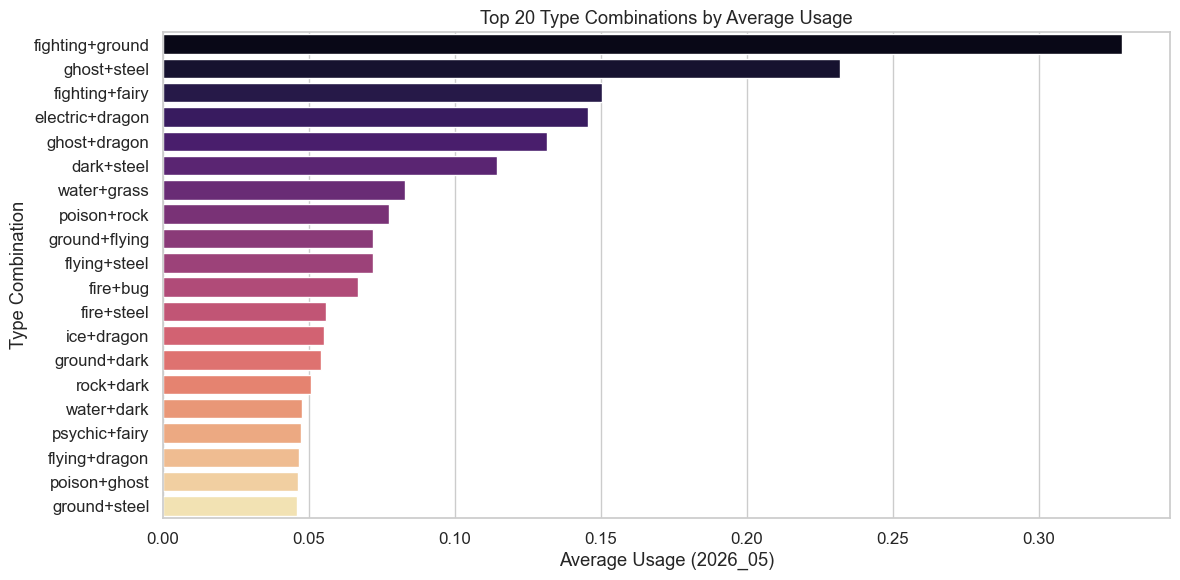

In [4]:
usage_col = 'usage_2026_05'

combo_usage = (
    df.groupby('type_combo')[usage_col]
      .mean()
      .reset_index()
      .sort_values(by=usage_col, ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=combo_usage.head(20), x=usage_col, y='type_combo', palette='magma')
plt.title('Top 20 Type Combinations by Average Usage')
plt.xlabel('Average Usage (2026_05)')
plt.ylabel('Type Combination')
plt.tight_layout()
plt.show()

## Stat Total vs Usage
Scatter plot of total stats against usage.

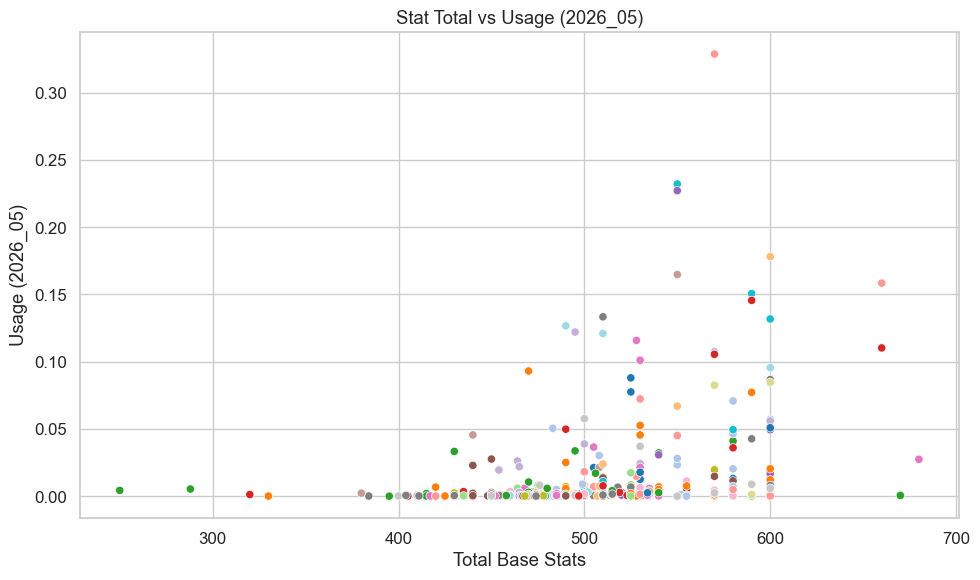

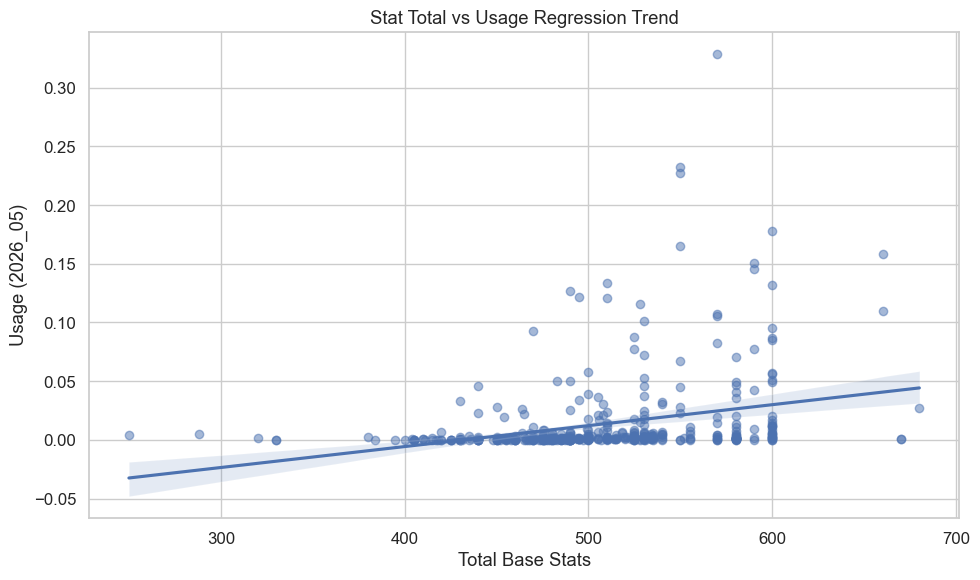

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='stat_total', y=usage_col, hue='type_combo', palette='tab20', legend=False)
plt.title('Stat Total vs Usage (2026_05)')
plt.xlabel('Total Base Stats')
plt.ylabel('Usage (2026_05)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='stat_total', y=usage_col, scatter_kws={'alpha': 0.5})
plt.title('Stat Total vs Usage Regression Trend')
plt.xlabel('Total Base Stats')
plt.ylabel('Usage (2026_05)')
plt.tight_layout()
plt.show()

## Stat Distribution vs Usage
Correlation matrix for base stats and usage.

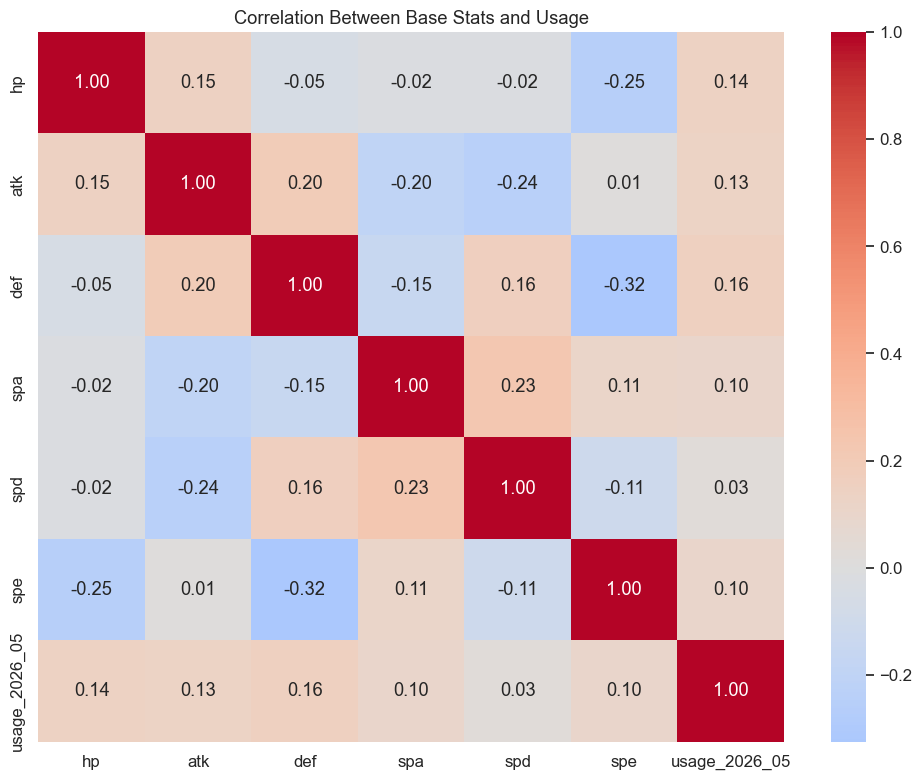

In [6]:
correlation_cols = stat_cols + [usage_col]
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Base Stats and Usage')
plt.tight_layout()
plt.show()

## Tier vs Usage
Compare average usage for each tier.

C:\Users\papi2\AppData\Local\Temp\ipykernel_4500\3210819241.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_usage, x='tier_label', y=usage_col, palette='viridis')


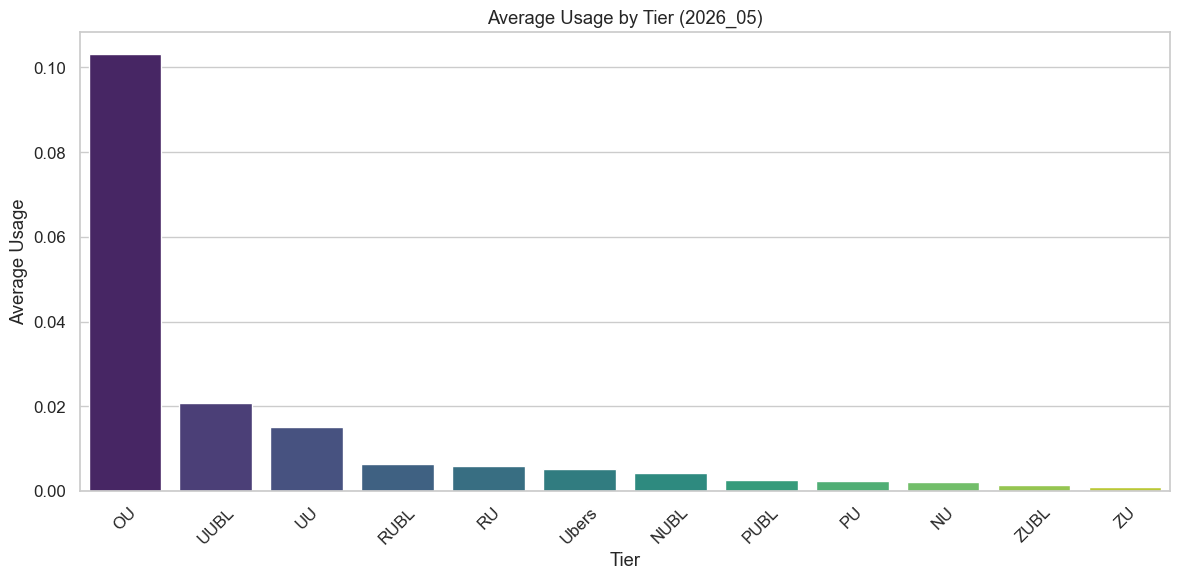

In [7]:
# Aggregate tier columns into a single tier label
tier_cols = [c for c in df.columns if c.startswith('tier_')]

def tier_label(row):
    tiers = [t.replace('tier_', '') for t in tier_cols if row[t] == 1]
    return tiers[0] if tiers else 'Unknown'

if 'tier_label' not in df.columns:
    df['tier_label'] = df.apply(tier_label, axis=1)

tier_usage = (
    df.groupby('tier_label')[usage_col]
      .mean()
      .reset_index()
      .sort_values(by=usage_col, ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=tier_usage, x='tier_label', y=usage_col, palette='viridis')
plt.title('Average Usage by Tier (2026_05)')
plt.xlabel('Tier')
plt.ylabel('Average Usage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analysis Notes
This notebook explores how type combinations, total base stat strength, stat distribution, and tier relate to usage. The `usage_2026_05` column is used since `usage_2026_06` is not available in the dataset.
